In [32]:
image_files = []

with open("pascal-voc-2012-dataset/VOC2012_train_val/VOC2012_train_val/ImageSets/Segmentation/train.txt") as f:
    for image_file in f:
        image_files.append(image_file.strip())

print(len(image_files))
print(image_files[:5])

base_path = "pascal-voc-2012-dataset/VOC2012_train_val/VOC2012_train_val/JPEGImages/"

image_paths = []
for image in image_files:
    image_paths.append(base_path + image + ".jpg")

print(len(image_paths))
print(image_paths[0])

1464
['2007_000032', '2007_000039', '2007_000063', '2007_000068', '2007_000121']
1464
pascal-voc-2012-dataset/VOC2012_train_val/VOC2012_train_val/JPEGImages/2007_000032.jpg


In [33]:
# need only one image to test slic algorithm
image_path = image_paths[0]
image_path

'pascal-voc-2012-dataset/VOC2012_train_val/VOC2012_train_val/JPEGImages/2007_000032.jpg'

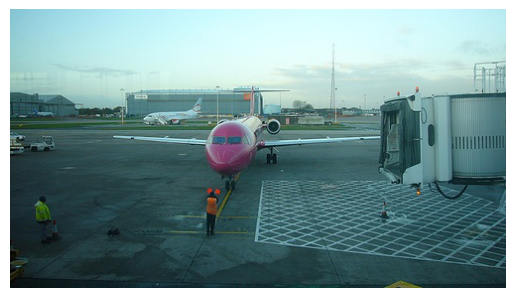

In [34]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

image = Image.open(image_path)
image = np.array(image)

plt.imshow(image)
plt.axis("off")
plt.show()

In [35]:
image.shape

(281, 500, 3)

In [36]:
N = image.shape[0] * image.shape[1]
K = 400
m = 10

In [37]:
S = np.sqrt(N / K)

In [38]:
print("N:", N)
print("K:", K)
print("S:", S)

N: 140500
K: 400
S: 18.741664813991314


In [39]:
import skimage

lab_image = skimage.color.rgb2lab(image)

In [40]:
lab_image.shape

(281, 500, 3)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-35.00926908386115..98.79509158732647].


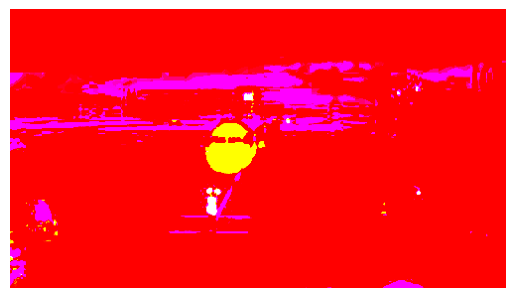

In [41]:
plt.imshow(lab_image)
plt.axis("off")
plt.show()

In [42]:
lower_lim = int(S / 2)
step_size = int(S)

In [43]:
cluster_centers = []

# initialize cluster centers
for y in range(lower_lim, lab_image.shape[0], step_size):
    for x in range(lower_lim, lab_image.shape[1], step_size):
        # create cluster center
        L = lab_image[y, x, 0]
        a = lab_image[y, x, 1]
        b = lab_image[y, x, 2]

        center = np.array([L, a, b, x, y])
        cluster_centers.append(center)

In [44]:
print(len(cluster_centers))

448


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-35.00926908386115..98.79509158732647].


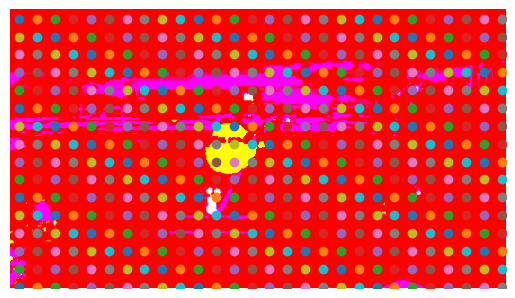

In [45]:
plt.imshow(lab_image)

for center in cluster_centers:
    plt.scatter(center[3], center[4])

plt.axis("off")
plt.show()

In [46]:
for i in range(0, len(cluster_centers)):
    # get x and y of each center
    center = cluster_centers[i]
    c_x, c_y = int(center[3]), int(center[4])

    # calculate gradient and update
    best_gradient = np.inf
    best_pos = (c_x, c_y)

    for dy in range(-1, 2):
        for dx in range(-1, 2):
            n_x = c_x + dx
            n_y = c_y + dy

            # check for boundaries
            if n_x <= 0 or n_x >= lab_image.shape[1] - 1:
                continue
            if n_y <= 0 or n_y >= lab_image.shape[0] - 1:
                continue

            # compute grad at (n_x, n_y)
            op1 = (lab_image[n_y + 1, n_x, 0] - lab_image[n_y - 1, n_x, 0]) ** 2
            op2 = (lab_image[n_y, n_x + 1, 0] - lab_image[n_y, n_x - 1, 0]) ** 2
            gradient = op1 + op2

            if gradient < best_gradient:
                best_gradient = gradient
                best_pos = (n_x, n_y)
    
    # move center
    new_x, new_y = best_pos
    
    cluster_centers[i][3] = new_x
    cluster_centers[i][4] = new_y

    # update L, a, b values
    cluster_centers[i][0] = lab_image[new_y, new_x, 0]
    cluster_centers[i][1] = lab_image[new_y, new_x, 1]
    cluster_centers[i][2] = lab_image[new_y, new_x, 2]

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-35.00926908386115..98.79509158732647].


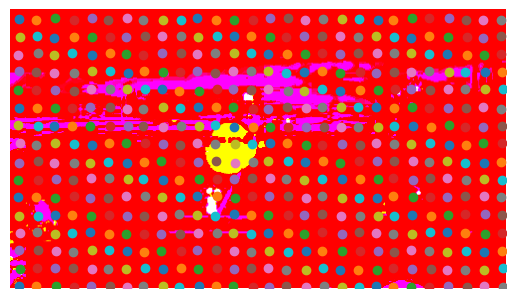

In [47]:
plt.imshow(lab_image)

for center in cluster_centers:
    plt.scatter(center[3], center[4])

plt.axis("off")
plt.show()

In [55]:
# array to maintain best distances seen so far for each pixel
img_height = lab_image.shape[0]
img_width = lab_image.shape[1]
distance = np.full((img_height, img_width), np.inf)

# array to maintain which cluster each pixel belongs to
labels = np.full((img_height, img_width), -1)

In [54]:
compactness = (m / S) ** 2
num_iterations = 10

In [56]:
for j in range(0, num_iterations):
    # reset distance after every iteration
    distance.fill(np.inf)

    # pixel assignment  
    for i in range(0, len(cluster_centers)):
        # get (c_x, c_y, L_c, a_c, b_c)
        center = cluster_centers[i]
        c_x, c_y = int(center[3]), int(center[4])
        L_c, a_c, b_c = center[0], center[1], center[2] 

        # define the search window
        x_start = max(c_x - int(S), 0)
        x_end = min(c_x + int(S), img_width)

        y_start = max(c_y - int(S), 0)
        y_end = min(c_y + int(S), img_height)

        # iterate over pixels in this window
        for y in range(y_start, y_end):
            for x in range(x_start, x_end):
                L, a, b = lab_image[y, x, 0], lab_image[y, x, 1], lab_image[y, x, 2]

                # calculate colour and spatial distance
                dc_2 = (L - L_c) ** 2 + (a - a_c) ** 2 + (b - b_c) ** 2
                ds_2 = (x - c_x) ** 2 + (y - c_y) ** 2

                # calculate combined distance
                D = dc_2 + compactness * ds_2

                if D < distance[y, x]:
                    distance[y, x] = D
                    labels[y, x] = i

    # update the centers
    size = len(cluster_centers)

    sum_L = np.zeros(size)
    sum_a = np.zeros(size)
    sum_b = np.zeros(size)
    sum_x = np.zeros(size)
    sum_y = np.zeros(size)
    count = np.zeros(size)

    # loop through each pixel and accumulate
    for y in range(img_height):
        for x in range(img_width):
            cluster_id = labels[y, x]

            L, a, b = lab_image[y, x]

            sum_L[cluster_id] += L
            sum_a[cluster_id] += a
            sum_b[cluster_id] += b
            sum_x[cluster_id] += x
            sum_y[cluster_id] += y
            count[cluster_id] += 1

    # actually update the centers now
    for i in range(size):

        # keep the old center if count is 0
        if count[i] == 0:
            continue

        cluster_centers[i][0] = sum_L[i] / count[i]
        cluster_centers[i][1] = sum_a[i] / count[i]
        cluster_centers[i][2] = sum_b[i] / count[i]
        cluster_centers[i][3] = sum_x[i] / count[i]
        cluster_centers[i][4] = sum_y[i] / count[i]

In [51]:
print(np.any(labels == -1))
print(len(np.unique(labels)))

False
448


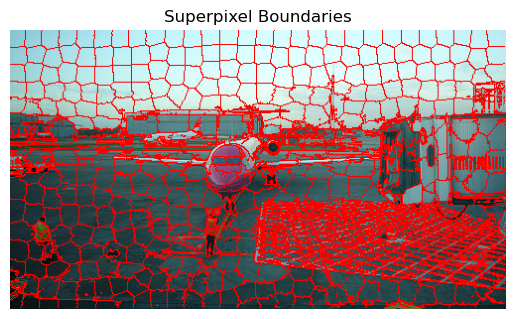

In [52]:
# visualizing the image after forming superpixels
output = image.copy()
boundary_color = np.array([255, 0, 0])

for y in range(img_height - 1):
    for x in range(img_width - 1):

        if (labels[y, x] != labels[y, x + 1]) or (labels[y, x] != labels[y + 1, x]):
            output[y, x] = boundary_color

plt.imshow(output)
plt.title("Superpixel Boundaries")
plt.axis('off')
plt.show()

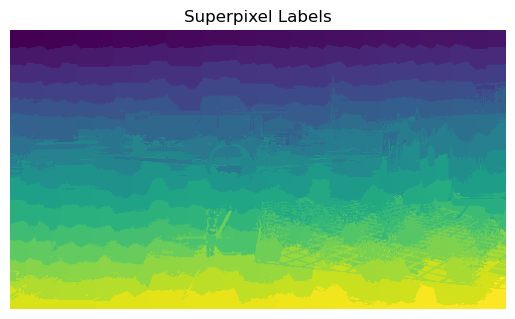

In [53]:
plt.imshow(labels)
plt.title("Superpixel Labels")
plt.axis('off')
plt.show()